# SNN for Spiking Heidelberg Digits (SHD)

**Goal**: Reproduce and exceed the baselines from Cramer et al. (2020) on the SHD dataset

**Paper targets**:
| Architecture | SHD Test Accuracy |
|---|---|
| 2-Layer Feed-Forward | 48.6% |
| Recurrent SNN (RSNN) | 71.4% |
| RSNN Best Effort (1024 neurons + augmentation) | 83.2% |
| LSTM | 89.0% |
| CNN | 92.4% |

Added dropout on recurrent connections, fixed channel jitter scaling for compressed inputs, corrected Best Effort experiment

In [1]:
import sys
import subprocess

print("Installing snntorch...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "snntorch", "-q"])
print("✓ Done!")

Installing snntorch...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.4 MB/s eta 0:00:00
✓ Done!


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import h5py
from collections import OrderedDict
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 1. Load the Spiking Heidelberg Digits Dataset

In [3]:
DATA_DIR = "/kaggle/input/datasets/harshitad879/shd-snns-dataset"
train_path = os.path.join(DATA_DIR, "shd_train.h5")
test_path = os.path.join(DATA_DIR, "shd_test.h5")

print("Dataset files:")
for f in [train_path, test_path]:
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {f}: {size_mb:.1f} MB")

Dataset files:
  /kaggle/input/datasets/harshitad879/shd-snns-dataset/shd_train.h5: 268.8 MB
  /kaggle/input/datasets/harshitad879/shd-snns-dataset/shd_test.h5: 78.7 MB


## 2. Explore Dataset Structure

=== HDF5 Structure ===
  extra: Group
  extra/keys: Dataset shape=(20,) dtype=|S6
  extra/meta_info: Group
  extra/meta_info/age: Dataset shape=(12,) dtype=uint16
  extra/meta_info/body_height: Dataset shape=(12,) dtype=uint16
  extra/meta_info/gender: Dataset shape=(12,) dtype=|S6
  extra/speaker: Dataset shape=(8156,) dtype=uint16
  labels: Dataset shape=(8156,) dtype=uint16
  spikes: Group
  spikes/times: Dataset shape=(8156,) dtype=object
  spikes/units: Dataset shape=(8156,) dtype=object

=== Training Set ===
Samples: 8156
Classes: 20
Label range: 0 to 19

=== Sample Spike Stats (first 100) ===
Spikes per sample: 8122 +/- 2585
Max spike time: 1.1562 s
Max unit index: 699 (=> 700 input channels)

=== Test Set: 2264 samples ===


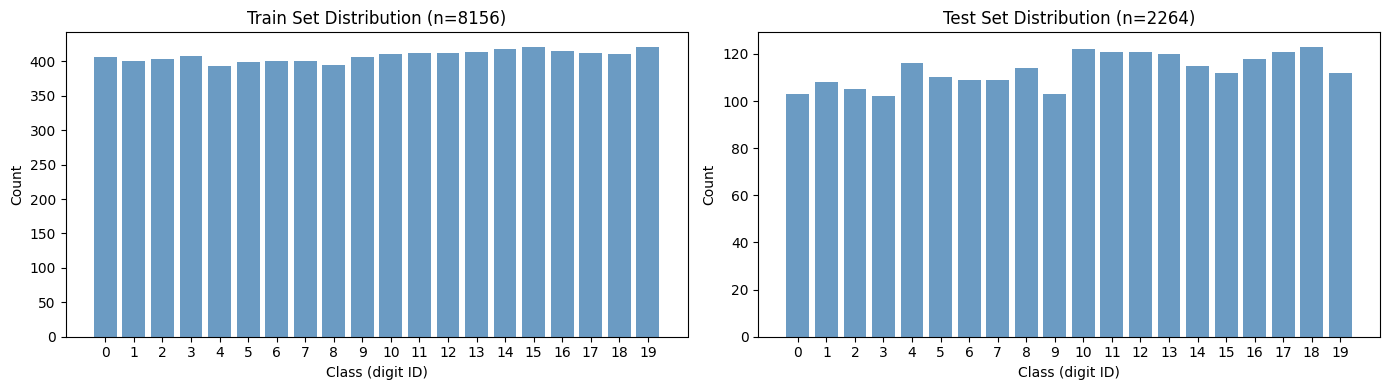

In [4]:
with h5py.File(train_path, 'r') as f:
    print("=== HDF5 Structure ===")
    def print_structure(name, obj):
        print(f"  {name}: {type(obj).__name__}", end="")
        if hasattr(obj, 'shape'):
            print(f" shape={obj.shape} dtype={obj.dtype}")
        else:
            print()
    f.visititems(print_structure)

    n_train = len(f['labels'])
    labels_explore = f['labels'][:]
    print(f"\n=== Training Set ===")
    print(f"Samples: {n_train}")
    print(f"Classes: {len(np.unique(labels_explore))}")
    print(f"Label range: {labels_explore.min()} to {labels_explore.max()}")

    print(f"\n=== Sample Spike Stats (first 100) ===")
    n_spikes_list, max_times, max_units = [], [], []
    for i in range(min(100, n_train)):
        times = f['spikes/times'][i]
        units = f['spikes/units'][i]
        n_spikes_list.append(len(times))
        if len(times) > 0:
            max_times.append(times.max())
            max_units.append(int(units.max()))
    print(f"Spikes per sample: {np.mean(n_spikes_list):.0f} +/- {np.std(n_spikes_list):.0f}")
    print(f"Max spike time: {np.max(max_times):.4f} s")
    print(f"Max unit index: {np.max(max_units)} (=> {np.max(max_units)+1} input channels)")

with h5py.File(test_path, 'r') as f:
    n_test = len(f['labels'])
    test_labels_explore = f['labels'][:]
    print(f"\n=== Test Set: {n_test} samples ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, lbls) in zip(axes, [("Train", labels_explore), ("Test", test_labels_explore)]):
    unique, counts = np.unique(lbls, return_counts=True)
    ax.bar(unique, counts, color='steelblue', alpha=0.8)
    ax.set_xlabel("Class (digit ID)")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} Set Distribution (n={len(lbls)})")
    ax.set_xticks(unique)
plt.tight_layout()
plt.show()

## 3. Dataset & Spike Binning

Key parameters from Cramer et al.:
- Simulation duration: **1.0s**, Number of input channels: **700** bushy cells
- Channel jitter sigma must be **proportional to channel count** (paper uses 20/700 = 2.8%)

In [5]:
class SHDDataset(Dataset):
    def __init__(self, h5_path, n_time_bins=100, n_channels=700, max_time=1.0,
                 channel_jitter_sigma=0, augment=False):
        self.n_time_bins = n_time_bins
        self.n_channels = n_channels
        self.max_time = max_time
        self.channel_jitter_sigma = channel_jitter_sigma
        self.augment = augment
        self.dt = max_time / n_time_bins
        self.channel_factor = 700 // n_channels

        with h5py.File(h5_path, 'r') as f:
            self.labels = f['labels'][:].astype(np.int64)
            self.spike_times = []
            self.spike_units = []
            for i in range(len(self.labels)):
                self.spike_times.append(f['spikes/times'][i].astype(np.float32))
                self.spike_units.append(f['spikes/units'][i].astype(np.int32))

        self.n_samples = len(self.labels)
        self.n_classes = len(np.unique(self.labels))

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        times = self.spike_times[idx]
        units = self.spike_units[idx].copy()
        label = self.labels[idx]

        # Channel jitter BEFORE compression (on 700-channel space)
        # This is the correct order — paper applies jitter to raw unit indices
        if self.augment and self.channel_jitter_sigma > 0:
            jitter = np.random.normal(0, self.channel_jitter_sigma, size=len(units))
            units = np.clip(np.round(units + jitter).astype(np.int32), 0, 699)

        # Channel compression AFTER jitter
        if self.channel_factor > 1:
            units = units // self.channel_factor

        spike_tensor = np.zeros((self.n_time_bins, self.n_channels), dtype=np.float32)
        for t, u in zip(times, units):
            time_bin = int(t / self.dt)
            if 0 <= time_bin < self.n_time_bins and 0 <= u < self.n_channels:
                spike_tensor[time_bin, u] += 1.0

        return torch.tensor(spike_tensor), torch.tensor(label, dtype=torch.long)


def create_dataloaders(n_time_bins=100, n_channels=700, batch_size=256,
                       channel_jitter_sigma=0, num_workers=2):
    train_ds = SHDDataset(
        train_path, n_time_bins=n_time_bins, n_channels=n_channels,
        channel_jitter_sigma=channel_jitter_sigma, augment=True
    )
    test_ds = SHDDataset(
        test_path, n_time_bins=n_time_bins, n_channels=n_channels,
        channel_jitter_sigma=0, augment=False
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)
    print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
    print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")
    print(f"Input shape: [{n_time_bins}, {n_channels}], Classes: {train_ds.n_classes}")
    return train_loader, test_loader, train_ds.n_classes

train_loader, test_loader, n_classes = create_dataloaders(n_time_bins=100, n_channels=700, batch_size=256)
x_sample, y_sample = next(iter(train_loader))
print(f"\nBatch shape: {x_sample.shape}, Spikes per sample: {x_sample[0].sum():.0f}")

Train: 8156 samples, 31 batches
Test:  2264 samples, 9 batches
Input shape: [100, 700], Classes: 20

Batch shape: torch.Size([256, 100, 700]), Spikes per sample: 8663


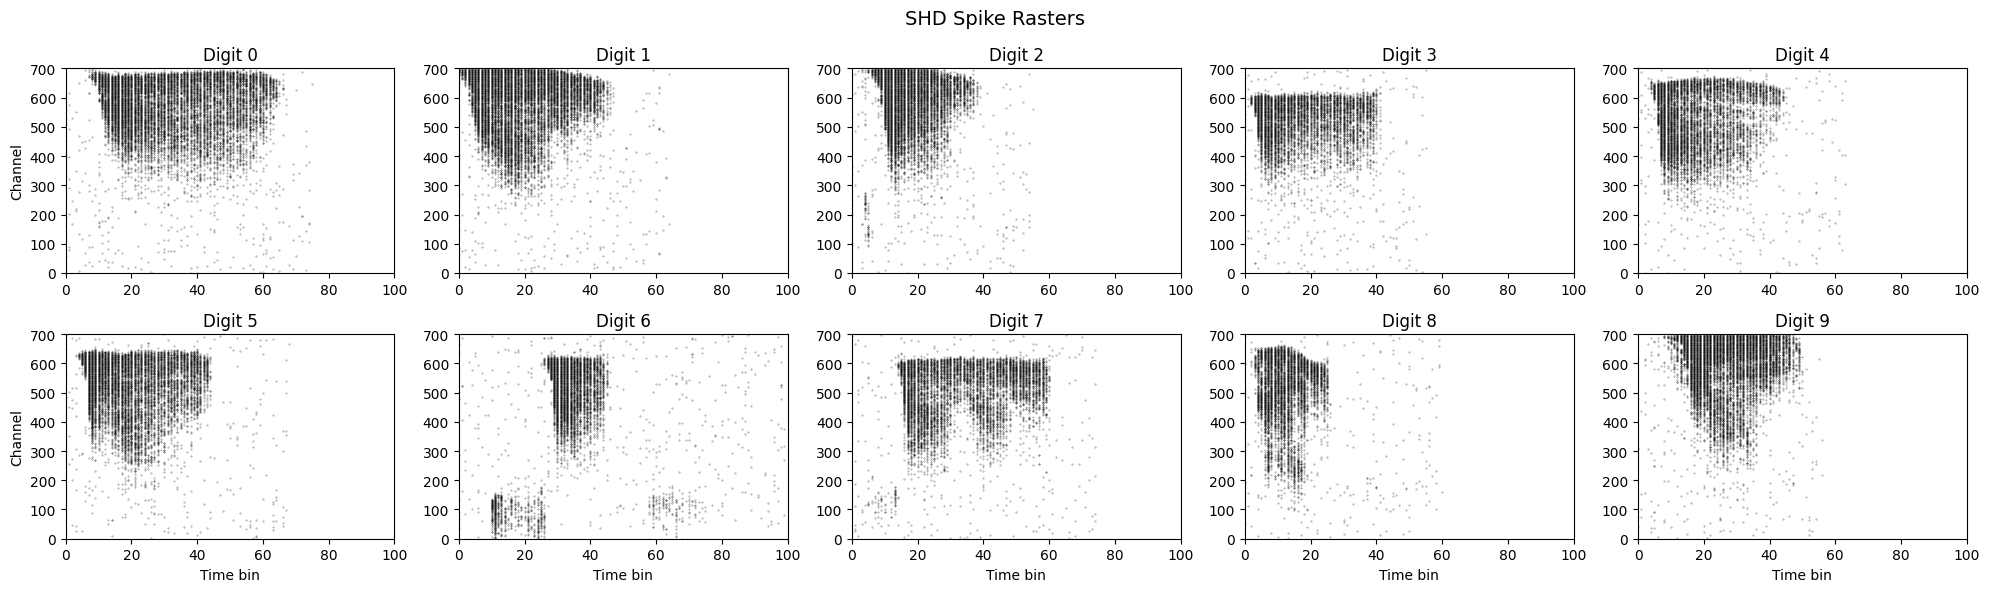

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
shown_classes = set()
for x_batch, y_batch in train_loader:
    for i in range(len(y_batch)):
        cls = y_batch[i].item()
        if cls < 10 and cls not in shown_classes:
            ax = axes[cls // 5, cls % 5]
            spike_t, spike_u = np.where(x_batch[i].numpy() > 0)
            ax.scatter(spike_t, spike_u, s=0.1, c='black', alpha=0.5)
            ax.set_title(f"Digit {cls}")
            ax.set_xlim(0, 100); ax.set_ylim(0, 700)
            if cls % 5 == 0: ax.set_ylabel("Channel")
            if cls >= 5: ax.set_xlabel("Time bin")
            shown_classes.add(cls)
    if len(shown_classes) >= 10: break
plt.suptitle("SHD Spike Rasters", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Spiking Neural Network Components

Surrogate gradient: fast sigmoid (Eq. 8) with $\beta=40$.
LIF dynamics: Eqs. 5-6 with current-based synapses.

In [7]:
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane_potential, threshold=1.0):
        ctx.save_for_backward(membrane_potential)
        ctx.threshold = threshold
        return (membrane_potential >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        membrane_potential, = ctx.saved_tensors
        beta = SurrogateSpike.beta
        v = membrane_potential - ctx.threshold
        grad = 1.0 / (1.0 + beta * torch.abs(v)) ** 2
        return grad_output * grad, None

SurrogateSpike.beta = 40.0

def spike_fn(x, threshold=1.0):
    return SurrogateSpike.apply(x, threshold)

# Verify
test_u = torch.randn(5, requires_grad=True)
spikes = spike_fn(test_u)
spikes.sum().backward()
print(f"Membrane: {test_u.data.numpy().round(3)}")
print(f"Spikes:   {spikes.data.numpy()}")
print(f"Grads:    {test_u.grad.numpy().round(4)}")
print("Surrogate gradient OK")

Membrane: [-1.123 -0.186  2.208 -0.638  0.462]
Spikes:   [0. 0. 1. 0. 0.]
Grads:    [0.0001 0.0004 0.0004 0.0002 0.002 ]
Surrogate gradient OK


In [8]:
class LIFLayer(nn.Module):
    """
    LIF layer (Cramer et al. Eqs. 5-6) with dropout on recurrent connections.
    Dropout on recurrent spikes is essential to prevent overfitting in RSNNs.
    """
    def __init__(self, input_size, hidden_size, recurrent=False,
                 tau_mem_init=20.0, tau_syn_init=10.0, dt=10.0,
                 learnable_tau=False, dropout=0.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.recurrent = recurrent
        self.dt = dt
        self.dropout = dropout

        self.W_ff = nn.Linear(input_size, hidden_size, bias=False)
        if recurrent:
            self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)

        if learnable_tau:
            self.log_tau_mem = nn.Parameter(torch.tensor(np.log(tau_mem_init)))
            self.log_tau_syn = nn.Parameter(torch.tensor(np.log(tau_syn_init)))
        else:
            self.register_buffer('log_tau_mem', torch.tensor(np.log(tau_mem_init)))
            self.register_buffer('log_tau_syn', torch.tensor(np.log(tau_syn_init)))
        self.learnable_tau = learnable_tau

        nn.init.kaiming_uniform_(self.W_ff.weight, nonlinearity='linear')
        if recurrent:
            nn.init.kaiming_uniform_(self.W_rec.weight, nonlinearity='linear')

    @property
    def alpha(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_syn))

    @property
    def beta(self):
        return torch.exp(-self.dt / torch.exp(self.log_tau_mem))

    def forward(self, x):
        batch_size, n_steps, _ = x.shape
        alpha, beta = self.alpha, self.beta

        syn = torch.zeros(batch_size, self.hidden_size, device=x.device)
        mem = torch.zeros(batch_size, self.hidden_size, device=x.device)
        prev_spk = torch.zeros(batch_size, self.hidden_size, device=x.device)

        spike_rec, mem_rec = [], []

        for t in range(n_steps):
            syn = alpha * syn + self.W_ff(x[:, t, :])
            if self.recurrent:
                # Dropout on recurrent spikes — key regularization
                rec_spk = F.dropout(prev_spk, p=self.dropout, training=self.training) if self.dropout > 0 else prev_spk
                syn = syn + self.W_rec(rec_spk)

            mem = beta * mem * (1.0 - prev_spk) + (1.0 - beta) * syn
            spk = spike_fn(mem, threshold=1.0)

            spike_rec.append(spk)
            mem_rec.append(mem)
            prev_spk = spk

        return torch.stack(spike_rec, dim=1), torch.stack(mem_rec, dim=1)

# Sanity check
layer = LIFLayer(700, 128, recurrent=True, dropout=0.2).to(device)
dummy = torch.randn(4, 100, 700).to(device)
spk, mem = layer(dummy)
print(f"LIF layer: {dummy.shape} -> spikes {spk.shape}, rate={spk.mean():.4f}")

LIF layer: torch.Size([4, 100, 700]) -> spikes torch.Size([4, 100, 128]), rate=0.0367


In [9]:
class ReadoutLayer(nn.Module):
    def __init__(self, input_size, output_size, tau_mem=20.0, dt=10.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size, bias=False)
        self.beta = np.exp(-dt / tau_mem)
        nn.init.kaiming_uniform_(self.fc.weight, nonlinearity='linear')

    def forward(self, x):
        batch_size, n_steps, _ = x.shape
        mem = torch.zeros(batch_size, self.fc.out_features, device=x.device)
        mem_rec = []
        for t in range(n_steps):
            mem = self.beta * mem + (1 - self.beta) * self.fc(x[:, t, :])
            mem_rec.append(mem)
        return torch.stack(mem_rec, dim=1)

## 5. Complete SNN Architecture

In [10]:
class SNN(nn.Module):
    def __init__(self, input_size=700, hidden_size=128, output_size=20,
                 n_hidden_layers=1, recurrent=False,
                 tau_mem=20.0, tau_syn=10.0, dt=10.0,
                 learnable_tau=False, loss_mode='max_over_time',
                 dropout=0.0):
        super().__init__()
        self.loss_mode = loss_mode
        self.hidden_size = hidden_size
        self.n_hidden_layers = n_hidden_layers
        self.recurrent = recurrent

        layers = []
        for i in range(n_hidden_layers):
            in_sz = input_size if i == 0 else hidden_size
            layers.append(LIFLayer(
                in_sz, hidden_size, recurrent=recurrent,
                tau_mem_init=tau_mem, tau_syn_init=tau_syn, dt=dt,
                learnable_tau=learnable_tau, dropout=dropout
            ))
        self.hidden_layers = nn.ModuleList(layers)
        self.readout = ReadoutLayer(hidden_size, output_size, tau_mem=tau_mem, dt=dt)

    def forward(self, x):
        all_spikes = []
        h = x
        for layer in self.hidden_layers:
            spikes, _ = layer(h)
            all_spikes.append(spikes)
            h = spikes
        out_mem = self.readout(h)

        if self.loss_mode == 'max_over_time':
            output, _ = torch.max(out_mem, dim=1)
        elif self.loss_mode == 'last_timestep':
            output = out_mem[:, -1, :]
        else:
            raise ValueError(f"Unknown loss_mode: {self.loss_mode}")
        return output, all_spikes, out_mem

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Architecture comparison:")
print("-" * 60)
for name, kwargs in [
    ("2L Feed-Forward", dict(n_hidden_layers=2, recurrent=False)),
    ("RSNN 128 + dropout", dict(n_hidden_layers=1, recurrent=True, dropout=0.2)),
    ("RSNN 256 + dropout", dict(n_hidden_layers=1, recurrent=True, hidden_size=256, dropout=0.3)),
    ("RSNN 512 + dropout", dict(n_hidden_layers=1, recurrent=True, hidden_size=512, dropout=0.3)),
]:
    m = SNN(**kwargs).to(device)
    print(f"  {name:25s}: {m.count_params():>8,} params")
    del m

Architecture comparison:
------------------------------------------------------------
  2L Feed-Forward          :  108,544 params
  RSNN 128 + dropout       :  108,544 params
  RSNN 256 + dropout       :  249,856 params
  RSNN 512 + dropout       :  630,784 params


## 6. Spike Regularization (Eqs. 10-11)

In [11]:
def spike_regularization(all_spikes, theta_l=0.01, s_l=1.0, theta_u=100.0, s_u=0.06):
    reg_loss = torch.tensor(0.0, device=all_spikes[0].device)
    for spikes in all_spikes:
        batch_size, T, N = spikes.shape
        mean_rate = spikes.sum(dim=1) / T
        lower_violation = F.relu(theta_l - mean_rate)
        L1 = s_l / (batch_size * N) * (lower_violation ** 2).sum()
        pop_count = spikes.sum(dim=(1, 2)) / N
        upper_violation = F.relu(pop_count - theta_u)
        L2 = s_u / batch_size * (upper_violation ** 2).sum()
        reg_loss = reg_loss + L1 + L2
    return reg_loss

dummy_lo = [torch.rand(4, 100, 128).to(device) > 0.95]
dummy_hi = [torch.rand(4, 100, 128).to(device) > 0.1]
print(f"Reg loss (5% rate):  {spike_regularization(dummy_lo).item():.4f}")
print(f"Reg loss (90% rate): {spike_regularization(dummy_hi).item():.4f}")

Reg loss (5% rate):  0.0000
Reg loss (90% rate): 0.0000


## 7. Training Engine (with early stopping)

In [12]:
class Trainer:
    def __init__(self, model, train_loader, test_loader,
                 lr=1e-3, reg_params=None, device='cuda'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.device = device
        self.optimizer = torch.optim.Adamax(model.parameters(), lr=lr, betas=(0.9, 0.999))
        self.criterion = nn.CrossEntropyLoss()
        self.reg_params = reg_params or {'theta_l': 0.01, 's_l': 1.0, 'theta_u': 100.0, 's_u': 0.06}
        self.history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [],
                        'spike_rates': [], 'epoch_time': []}

    def train_epoch(self):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        spike_rates = []
        for x, y in self.train_loader:
            x, y = x.to(self.device), y.to(self.device)
            logits, all_spikes, _ = self.model(x)
            cls_loss = self.criterion(logits, y)
            reg_loss = spike_regularization(all_spikes, **self.reg_params)
            loss = cls_loss + reg_loss
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            total_loss += cls_loss.item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)
            for spk in all_spikes:
                spike_rates.append(spk.detach().mean().item())
        return total_loss / total, correct / total, np.mean(spike_rates)

    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0
        for x, y in self.test_loader:
            x, y = x.to(self.device), y.to(self.device)
            logits, _, _ = self.model(x)
            total_loss += self.criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)
        return total_loss / total, correct / total

    def train(self, n_epochs, patience=25, min_delta=0.001, verbose=True):
        best_test_acc = 0
        best_state = None
        no_improve = 0

        for epoch in range(n_epochs):
            t0 = time.time()
            tr_loss, tr_acc, spk_rate = self.train_epoch()
            te_loss, te_acc = self.evaluate()
            elapsed = time.time() - t0

            self.history['train_loss'].append(tr_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['test_loss'].append(te_loss)
            self.history['test_acc'].append(te_acc)
            self.history['spike_rates'].append(spk_rate)
            self.history['epoch_time'].append(elapsed)

            if te_acc > best_test_acc + min_delta:
                best_test_acc = te_acc
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

            if verbose and (epoch % 5 == 0 or epoch == n_epochs - 1 or no_improve >= patience):
                print(f"Epoch {epoch:3d}/{n_epochs} | "
                      f"Train: {tr_acc:.4f} ({tr_loss:.4f}) | "
                      f"Test: {te_acc:.4f} ({te_loss:.4f}) | "
                      f"Spk: {spk_rate:.4f} | "
                      f"Best: {best_test_acc:.4f} | "
                      f"Pat: {patience-no_improve}/{patience} | "
                      f"{elapsed:.1f}s")

            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break
        else:
            print(f"\nCompleted all {n_epochs} epochs")

        if best_state:
            self.model.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})
        print(f"Best test acc: {best_test_acc*100:.2f}% | Time: {sum(self.history['epoch_time'])/60:.1f} min")
        return best_test_acc

    def plot_history(self, title=""):
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        axes[0].plot(self.history['train_acc'], label='Train', alpha=0.8)
        axes[0].plot(self.history['test_acc'], label='Test', alpha=0.8)
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
        axes[0].set_title(f'{title} — Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
        axes[1].plot(self.history['train_loss'], label='Train', alpha=0.8)
        axes[1].plot(self.history['test_loss'], label='Test', alpha=0.8)
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
        axes[1].set_title(f'{title} — Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
        axes[2].plot(self.history['spike_rates'], color='green', alpha=0.8)
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Mean Spike Rate')
        axes[2].set_title(f'{title} — Spike Activity'); axes[2].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

print("Trainer ready")

Trainer ready


## 8. Experiment 1: 2-Layer Feed-Forward Baseline
**Paper**: 48.6%. **v1 result**: 51.2% (PASS)

EXPERIMENT 1: 2-Layer Feed-Forward SNN
Train: 8156 samples, 31 batches
Test:  2264 samples, 9 batches
Input shape: [100, 700], Classes: 20
Model: 108,544 params | 700->128 LIF->128 LIF->20
Epoch   0/100 | Train: 0.0650 (2.9865) | Test: 0.0689 (2.9699) | Spk: 0.0137 | Best: 0.0689 | Pat: 25/25 | 43.1s
Epoch   5/100 | Train: 0.1856 (2.6691) | Test: 0.2014 (2.6006) | Spk: 0.0327 | Best: 0.2014 | Pat: 25/25 | 42.4s
Epoch  10/100 | Train: 0.3173 (2.2728) | Test: 0.3176 (2.1932) | Spk: 0.0396 | Best: 0.3176 | Pat: 25/25 | 42.3s
Epoch  15/100 | Train: 0.3696 (2.0299) | Test: 0.3790 (1.9838) | Spk: 0.0435 | Best: 0.3790 | Pat: 25/25 | 42.5s
Epoch  20/100 | Train: 0.3972 (1.8765) | Test: 0.3931 (1.8732) | Spk: 0.0439 | Best: 0.3922 | Pat: 24/25 | 42.7s
Epoch  25/100 | Train: 0.4311 (1.7592) | Test: 0.4090 (1.7868) | Spk: 0.0448 | Best: 0.4117 | Pat: 24/25 | 41.5s
Epoch  30/100 | Train: 0.4573 (1.6630) | Test: 0.4280 (1.7166) | Spk: 0.0456 | Best: 0.4311 | Pat: 24/25 | 43.7s
Epoch  35/100 | Trai

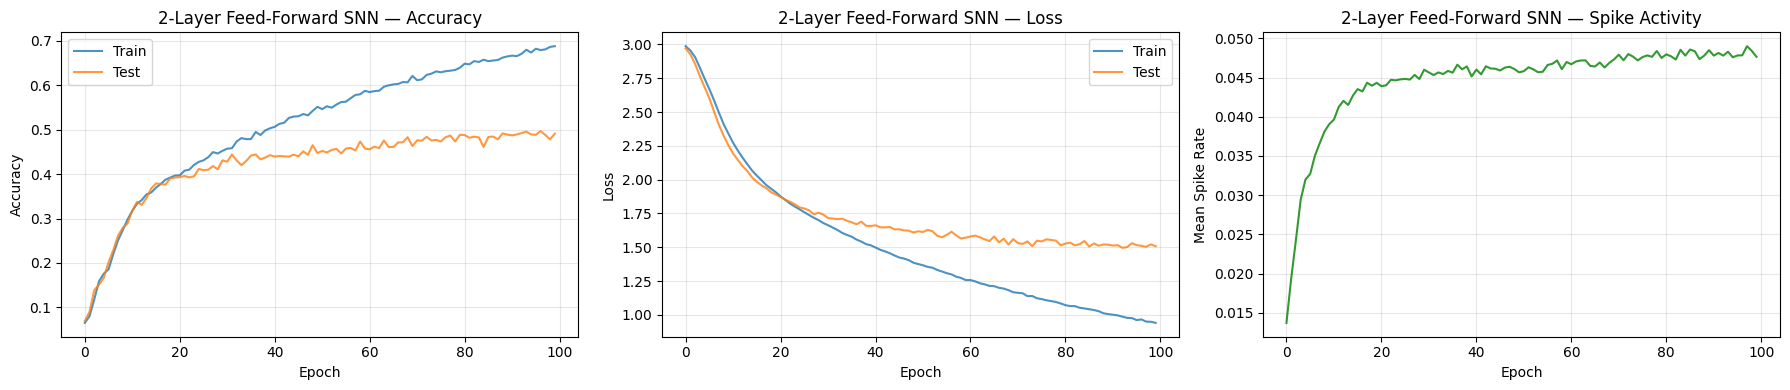

In [13]:
print("=" * 60)
print("EXPERIMENT 1: 2-Layer Feed-Forward SNN")
print("=" * 60)

train_loader, test_loader, n_classes = create_dataloaders(n_time_bins=100, n_channels=700, batch_size=256)

model_ff = SNN(input_size=700, hidden_size=128, output_size=n_classes,
               n_hidden_layers=2, recurrent=False,
               tau_mem=20.0, tau_syn=10.0, dt=10.0, loss_mode='max_over_time')

print(f"Model: {model_ff.count_params():,} params | 700->128 LIF->128 LIF->{n_classes}")

trainer_ff = Trainer(model_ff, train_loader, test_loader, lr=1e-3, device=device)
best_ff = trainer_ff.train(n_epochs=100)
trainer_ff.plot_history("2-Layer Feed-Forward SNN")

## 9. Experiment 2: RSNN 128 (with dropout)
**Paper**: 71.4%. **v1 result**: 53.7% (heavy overfitting). **Fix**: dropout=0.2 on recurrent spikes.

EXPERIMENT 2: RSNN 128 + dropout=0.2
Model: 108,544 params | 700->128 RLIF(drop=0.2)->20
Epoch   0/150 | Train: 0.0939 (2.9557) | Test: 0.1391 (2.9051) | Spk: 0.0228 | Best: 0.1391 | Pat: 25/25 | 42.2s
Epoch   5/150 | Train: 0.2656 (2.5956) | Test: 0.2875 (2.5281) | Spk: 0.0471 | Best: 0.2875 | Pat: 25/25 | 42.7s
Epoch  10/150 | Train: 0.3456 (2.3077) | Test: 0.3609 (2.2412) | Spk: 0.0664 | Best: 0.3609 | Pat: 25/25 | 41.8s
Epoch  15/150 | Train: 0.3931 (2.0444) | Test: 0.3609 (2.0134) | Spk: 0.0753 | Best: 0.3684 | Pat: 23/25 | 41.7s
Epoch  20/150 | Train: 0.4512 (1.8052) | Test: 0.4006 (1.8298) | Spk: 0.0849 | Best: 0.4028 | Pat: 24/25 | 41.4s
Epoch  25/150 | Train: 0.4966 (1.6236) | Test: 0.4245 (1.7026) | Spk: 0.0884 | Best: 0.4360 | Pat: 24/25 | 41.5s
Epoch  30/150 | Train: 0.5427 (1.4783) | Test: 0.4496 (1.6229) | Spk: 0.0936 | Best: 0.4554 | Pat: 24/25 | 43.4s
Epoch  35/150 | Train: 0.5817 (1.3625) | Test: 0.4814 (1.5423) | Spk: 0.0954 | Best: 0.4814 | Pat: 25/25 | 41.7s
Epoch  

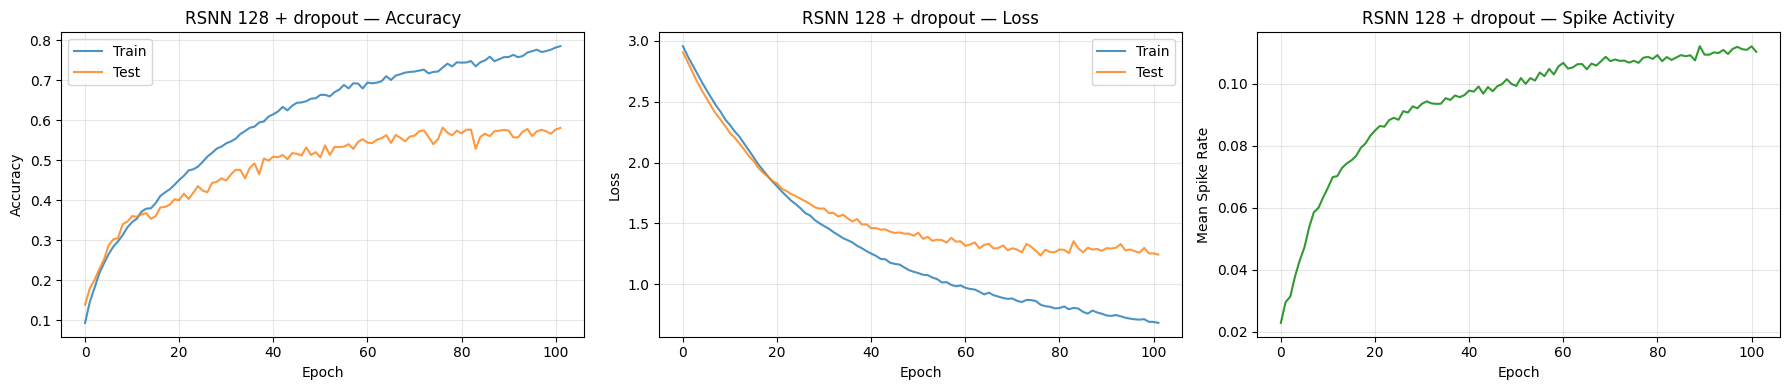

In [14]:
print("=" * 60)
print("EXPERIMENT 2: RSNN 128 + dropout=0.2")
print("=" * 60)

model_rsnn = SNN(input_size=700, hidden_size=128, output_size=n_classes,
                 n_hidden_layers=1, recurrent=True,
                 tau_mem=20.0, tau_syn=10.0, dt=10.0,
                 loss_mode='max_over_time', dropout=0.2)

print(f"Model: {model_rsnn.count_params():,} params | 700->128 RLIF(drop=0.2)->{n_classes}")

trainer_rsnn = Trainer(model_rsnn, train_loader, test_loader, lr=1e-3, device=device)
best_rsnn = trainer_rsnn.train(n_epochs=150)
trainer_rsnn.plot_history("RSNN 128 + dropout")

## 10. Experiment 3: RSNN 256 (with dropout)
**Paper**: ~73% (Fig. 8a). **v1 result**: 64.3% (heavy overfitting). **Fix**: dropout=0.3.

EXPERIMENT 3: RSNN 256 + dropout=0.3
Model: 249,856 params
Epoch   0/150 | Train: 0.1326 (2.9295) | Test: 0.1696 (2.8321) | Spk: 0.0185 | Best: 0.1696 | Pat: 25/25 | 42.2s
Epoch   5/150 | Train: 0.3266 (2.2873) | Test: 0.3410 (2.1885) | Spk: 0.0558 | Best: 0.3410 | Pat: 25/25 | 41.8s
Epoch  10/150 | Train: 0.4303 (1.8902) | Test: 0.4302 (1.8364) | Spk: 0.0703 | Best: 0.4298 | Pat: 24/25 | 42.4s
Epoch  15/150 | Train: 0.5150 (1.5924) | Test: 0.4589 (1.6120) | Spk: 0.0787 | Best: 0.4647 | Pat: 24/25 | 42.0s
Epoch  20/150 | Train: 0.5639 (1.3901) | Test: 0.5066 (1.4641) | Spk: 0.0865 | Best: 0.5066 | Pat: 25/25 | 41.7s
Epoch  25/150 | Train: 0.5959 (1.2481) | Test: 0.5102 (1.4000) | Spk: 0.0909 | Best: 0.5110 | Pat: 22/25 | 41.8s
Epoch  30/150 | Train: 0.6258 (1.1352) | Test: 0.5327 (1.3487) | Spk: 0.0931 | Best: 0.5402 | Pat: 24/25 | 42.1s
Epoch  35/150 | Train: 0.6579 (1.0432) | Test: 0.5296 (1.3309) | Spk: 0.0948 | Best: 0.5402 | Pat: 19/25 | 42.6s
Epoch  40/150 | Train: 0.6709 (0.9886

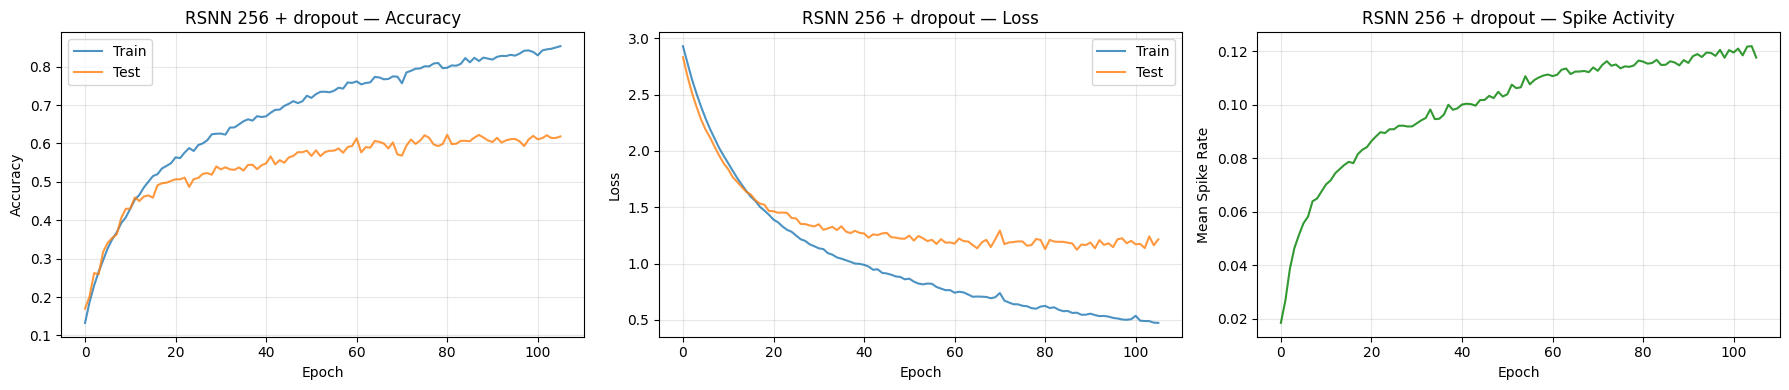

In [15]:
print("=" * 60)
print("EXPERIMENT 3: RSNN 256 + dropout=0.3")
print("=" * 60)

model_rsnn256 = SNN(input_size=700, hidden_size=256, output_size=n_classes,
                    n_hidden_layers=1, recurrent=True,
                    tau_mem=20.0, tau_syn=10.0, dt=10.0,
                    loss_mode='max_over_time', dropout=0.3)

print(f"Model: {model_rsnn256.count_params():,} params")

trainer_rsnn256 = Trainer(model_rsnn256, train_loader, test_loader, lr=1e-3, device=device)
best_rsnn256 = trainer_rsnn256.train(n_epochs=150)
trainer_rsnn256.plot_history("RSNN 256 + dropout")

## 11. Experiment 4: Best Effort RSNN

**Paper target: 83.2%**

EXPERIMENT 4: Best Effort RSNN (FIXED)
Train: 8156 samples, 31 batches
Test:  2264 samples, 9 batches
Input shape: [100, 70], Classes: 20
Model: 308,226 params
Architecture: 70->512 RLIF(drop=0.3, learnable tau)->20
Jitter: sigma=20 in 700-space, then compress to 70
Time constants: tau_mem=80ms, tau_syn=40ms (learnable)
Epoch   0/200 | Train: 0.1576 (2.8754) | Test: 0.1767 (2.7675) | Spk: 0.1415 | Best: 0.1767 | Pat: 30/30 | 43.1s
Epoch   5/200 | Train: 0.4848 (1.8497) | Test: 0.4845 (1.8519) | Spk: 0.1932 | Best: 0.4845 | Pat: 30/30 | 42.9s
Epoch  10/200 | Train: 0.6715 (1.1974) | Test: 0.5716 (1.3639) | Spk: 0.2886 | Best: 0.5716 | Pat: 30/30 | 43.7s
Epoch  15/200 | Train: 0.7816 (0.8075) | Test: 0.6290 (1.1166) | Spk: 0.3247 | Best: 0.6290 | Pat: 30/30 | 44.5s
Epoch  20/200 | Train: 0.8369 (0.5997) | Test: 0.6511 (1.0050) | Spk: 0.3398 | Best: 0.6621 | Pat: 29/30 | 43.2s
Epoch  25/200 | Train: 0.8686 (0.4880) | Test: 0.6829 (0.9389) | Spk: 0.3497 | Best: 0.6829 | Pat: 30/30 | 42.7s


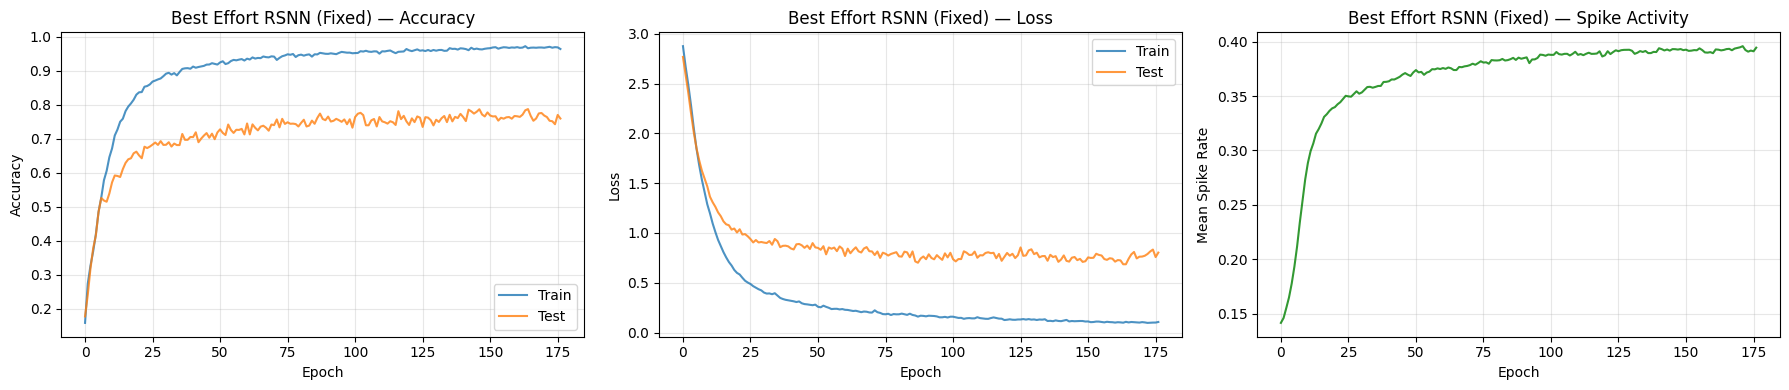

In [16]:
print("=" * 60)
print("EXPERIMENT 4: Best Effort RSNN (FIXED)")
print("=" * 60)

# Channel jitter sigma=20 is applied in 700-space BEFORE compression to 70
# This matches the paper's approach exactly
train_loader_aug, test_loader_aug, n_classes = create_dataloaders(
    n_time_bins=100,
    n_channels=70,                # Compressed 700->70
    batch_size=256,
    channel_jitter_sigma=20       # Applied in 700-space before compression (see Dataset class)
)

model_best = SNN(
    input_size=70,
    hidden_size=512,
    output_size=n_classes,
    n_hidden_layers=1,
    recurrent=True,
    tau_mem=80.0,                 # 4x scaled (paper Fig. 8c)
    tau_syn=40.0,
    dt=10.0,
    learnable_tau=True,
    loss_mode='max_over_time',
    dropout=0.3                   # Prevents overfitting
)

print(f"Model: {model_best.count_params():,} params")
print(f"Architecture: 70->512 RLIF(drop=0.3, learnable tau)->{n_classes}")
print(f"Jitter: sigma=20 in 700-space, then compress to 70")
print(f"Time constants: tau_mem=80ms, tau_syn=40ms (learnable)")

trainer_best = Trainer(model_best, train_loader_aug, test_loader_aug, lr=1e-3, device=device)
best_effort = trainer_best.train(n_epochs=200, patience=30)
trainer_best.plot_history("Best Effort RSNN (Fixed)")

## 12. Temporal Analysis

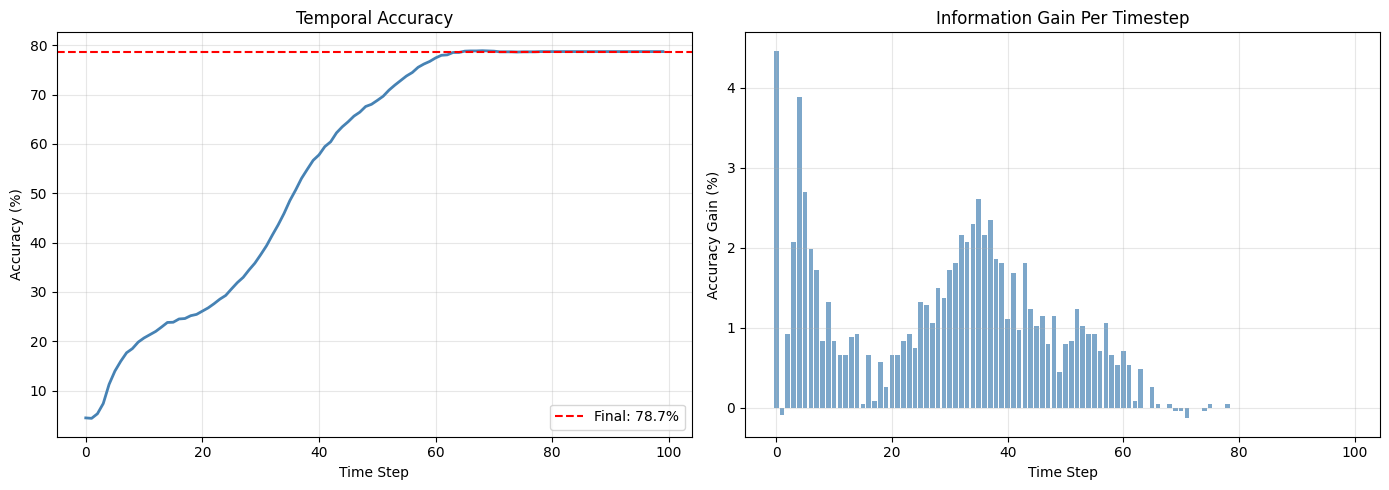

t=25 (250ms): 30.6%
t=50 (500ms): 68.8%
t=75 (750ms): 78.7%
t=99 (990ms): 78.7%


In [17]:
@torch.no_grad()
def temporal_analysis(model, test_loader, device, n_classes=20):
    model.eval()
    all_correct_at_t = []
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        _, _, out_mem = model(x)
        batch_size, n_steps, _ = out_mem.shape
        running_max = torch.full((batch_size, n_classes), -float('inf'), device=device)
        correct_at_t = torch.zeros(n_steps, device=device)
        for t in range(n_steps):
            running_max = torch.max(running_max, out_mem[:, t, :])
            correct_at_t[t] += (running_max.argmax(dim=1) == y).float().sum()
        all_correct_at_t.append(correct_at_t)
    total_correct = torch.stack(all_correct_at_t).sum(dim=0)
    total_samples = sum(len(y) for _, y in test_loader)
    return (total_correct / total_samples).cpu().numpy()

temporal_acc = temporal_analysis(model_best, test_loader_aug, device, n_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(temporal_acc * 100, linewidth=2, color='steelblue')
axes[0].axhline(y=best_effort * 100, color='red', linestyle='--', label=f'Final: {best_effort*100:.1f}%')
axes[0].set_xlabel('Time Step'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Temporal Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
acc_gain = np.diff(temporal_acc * 100, prepend=0)
axes[1].bar(range(len(acc_gain)), acc_gain, alpha=0.7, color='steelblue')
axes[1].set_xlabel('Time Step'); axes[1].set_ylabel('Accuracy Gain (%)')
axes[1].set_title('Information Gain Per Timestep'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"t=25 (250ms): {temporal_acc[25]*100:.1f}%")
print(f"t=50 (500ms): {temporal_acc[50]*100:.1f}%")
print(f"t=75 (750ms): {temporal_acc[75]*100:.1f}%")
print(f"t=99 (990ms): {temporal_acc[-1]*100:.1f}%")

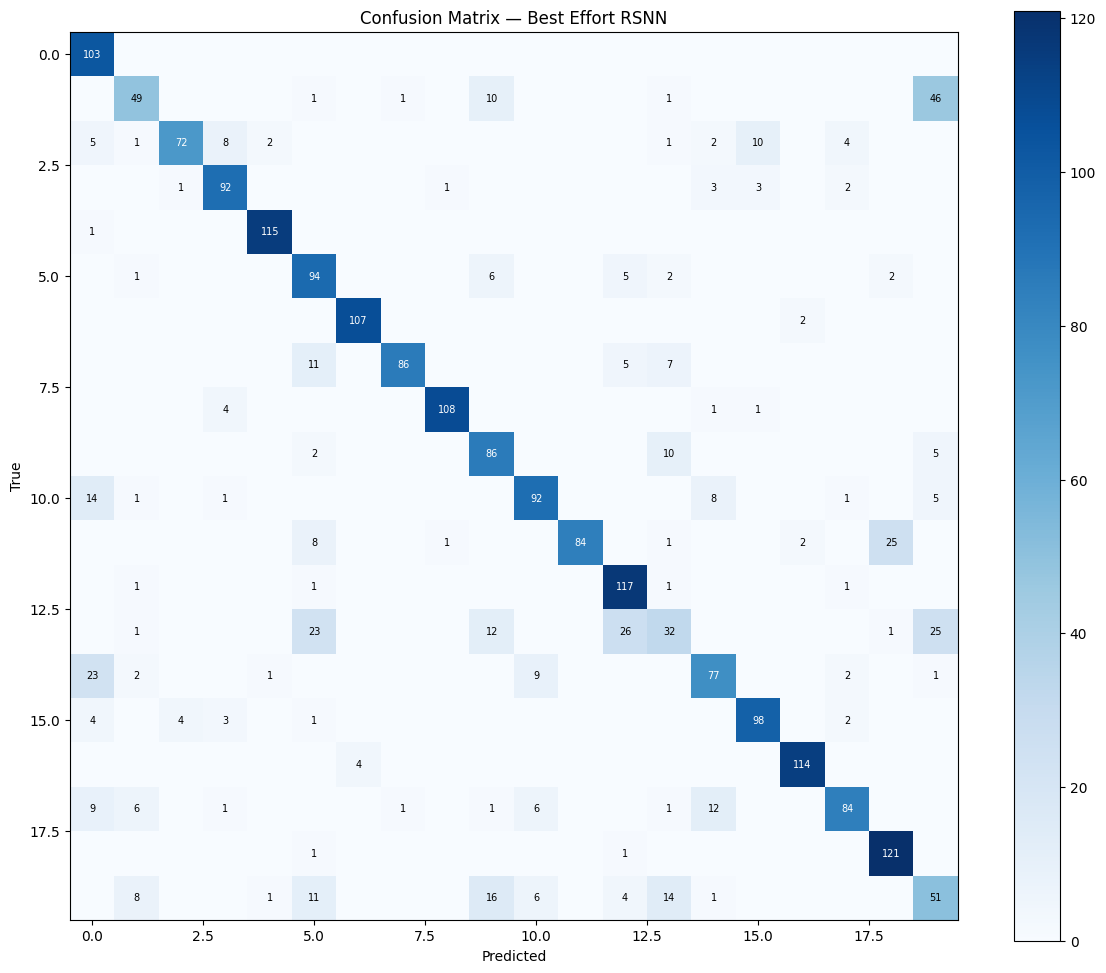

Per-class accuracy:
  Class  0: 100.0%
  Class  1: 45.4%
  Class  2: 68.6%
  Class  3: 90.2%
  Class  4: 99.1%
  Class  5: 85.5%
  Class  6: 98.2%
  Class  7: 78.9%
  Class  8: 94.7%
  Class  9: 83.5%
  Class 10: 75.4%
  Class 11: 69.4%
  Class 12: 96.7%
  Class 13: 26.7%
  Class 14: 67.0%
  Class 15: 87.5%
  Class 16: 96.6%
  Class 17: 69.4%
  Class 18: 98.4%
  Class 19: 45.5%
  Overall: 78.8%


In [18]:
from sklearn.metrics import confusion_matrix

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    preds, labels = [], []
    for x, y in loader:
        logits, _, _ = model(x.to(device))
        preds.append(logits.argmax(dim=1).cpu())
        labels.append(y)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()

preds, labels = get_predictions(model_best, test_loader_aug, device)
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Best Effort RSNN')
plt.colorbar(im)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=7)
plt.tight_layout(); plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
print("Per-class accuracy:")
for i, acc in enumerate(class_acc):
    print(f"  Class {i:2d}: {acc*100:.1f}%")
print(f"  Overall: {np.mean(class_acc)*100:.1f}%")

## 13. Results Summary

In [19]:
print("=" * 70)
print("RESULTS SUMMARY v2 — SHD Benchmark")
print("=" * 70)
print(f"{'Architecture':<35} {'Test Acc':>10} {'Paper':>10} {'Params':>10}")
print("-" * 70)
results = [
    ("2L Feed-Forward", best_ff, 0.486, model_ff.count_params()),
    ("RSNN 128 + dropout", best_rsnn, 0.714, model_rsnn.count_params()),
    ("RSNN 256 + dropout", best_rsnn256, 0.730, model_rsnn256.count_params()),
    ("Best Effort RSNN (fixed)", best_effort, 0.832, model_best.count_params()),
]
for name, acc, paper, params in results:
    s = "PASS" if acc >= paper * 0.95 else "BELOW"
    print(f"  {name:<33} {acc*100:>8.2f}% {paper*100:>8.1f}% {params:>10,} {s}")
print("-" * 70)
print(f"  {'LSTM (paper)':<33} {'--':>10} {'89.0%':>10}")
print(f"  {'CNN (paper)':<33} {'--':>10} {'92.4%':>10}")

import json
with open('/kaggle/working/shd_results_v2.json', 'w') as f:
    json.dump({n: a for n, a, _, _ in results}, f, indent=2)
print("\nSaved to shd_results_v2.json")

RESULTS SUMMARY v2 — SHD Benchmark
Architecture                          Test Acc      Paper     Params
----------------------------------------------------------------------
  2L Feed-Forward                      49.69%     48.6%    108,544 PASS
  RSNN 128 + dropout                   58.22%     71.4%    108,544 BELOW
  RSNN 256 + dropout                   62.28%     73.0%    249,856 BELOW
  Best Effort RSNN (fixed)             78.71%     83.2%    308,226 BELOW
----------------------------------------------------------------------
  LSTM (paper)                              --      89.0%
  CNN (paper)                               --      92.4%

Saved to shd_results_v2.json


In [20]:
save_path = '/kaggle/working/best_rsnn_shd_v2.pth'
torch.save({
    'model_state_dict': model_best.state_dict(),
    'model_config': dict(input_size=70, hidden_size=512, output_size=n_classes,
                         n_hidden_layers=1, recurrent=True, tau_mem=80.0, tau_syn=40.0,
                         dt=10.0, learnable_tau=True, loss_mode='max_over_time', dropout=0.3),
    'best_test_acc': best_effort,
    'history': trainer_best.history,
}, save_path)
print(f"Saved to {save_path} | Best acc: {best_effort*100:.2f}%")

Saved to /kaggle/working/best_rsnn_shd_v2.pth | Best acc: 78.71%


## 15. Baselines: LSTM and CNN

Train conventional architectures on the same binned spike data. The paper reports LSTM=89.0% and CNN=92.4%. Both use 700-channel input with 10ms bins (same as our `train_loader`/`test_loader`).

Match hidden size to 128 for LSTM (same as paper). CNN uses a simple 1D conv stack.

In [21]:
class LSTMBaseline(nn.Module):
    def __init__(self, input_size=700, hidden_size=128, n_layers=2,
                 output_size=20, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, n_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)  # out: [B, T, hidden]
        return out  # return full sequence for temporal analysis later

    def classify(self, x):
        """For training — classify using max-over-time on output logits."""
        out = self.forward(x)
        logits_seq = self.fc(out)  # [B, T, n_classes]
        logits, _ = logits_seq.max(dim=1)  # max over time
        return logits

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CNNBaseline(nn.Module):
    def __init__(self, input_channels=700, output_size=20):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=11, padding=5),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(256, output_size)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, T, C] -> [B, C, T]
        x = self.conv(x).squeeze(-1)
        return self.fc(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model_lstm = LSTMBaseline(input_size=700, hidden_size=128, output_size=n_classes)
model_cnn = CNNBaseline(input_channels=700, output_size=n_classes)
print(f"LSTM: {model_lstm.count_params():,} params")
print(f"CNN:  {model_cnn.count_params():,} params")

LSTM: 559,636 params
CNN:  720,468 params


In [22]:
def train_lstm(model, train_loader, test_loader, n_epochs=80, lr=1e-3,
               device='cuda'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_acc, best_state = 0, None

    for epoch in range(n_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model.classify(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = model.classify(x)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)
        test_acc = correct / total
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"  Epoch {epoch}: test={test_acc:.4f} (best={best_acc:.4f})")

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"  Best: {best_acc*100:.2f}%")
    return best_acc


def train_cnn(model, train_loader, test_loader, n_epochs=80, lr=1e-3,
              device='cuda'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_acc, best_state = 0, None

    for epoch in range(n_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)
        test_acc = correct / total
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"  Epoch {epoch}: test={test_acc:.4f} (best={best_acc:.4f})")

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"  Best: {best_acc*100:.2f}%")
    return best_acc

In [23]:
# uses train_loader/test_loader (700 channels) — same data as experiments 1-3
print("=" * 60)
print("BASELINE: LSTM (2-layer, 128 units, max-over-time)")
print("=" * 60)
acc_lstm = train_lstm(model_lstm, train_loader, test_loader,
                      n_epochs=80, lr=1e-3, device=device)

print()
print("=" * 60)
print("BASELINE: 1D-CNN")
print("=" * 60)
acc_cnn = train_cnn(model_cnn, train_loader, test_loader,
                    n_epochs=80, lr=1e-3, device=device)

BASELINE: LSTM (2-layer, 128 units, max-over-time)
  Epoch 0: test=0.3326 (best=0.3326)
  Epoch 10: test=0.8640 (best=0.8640)
  Epoch 20: test=0.8701 (best=0.8701)
  Epoch 30: test=0.8843 (best=0.8843)
  Epoch 40: test=0.8812 (best=0.8940)
  Epoch 50: test=0.8869 (best=0.8940)
  Epoch 60: test=0.8860 (best=0.8940)
  Epoch 70: test=0.8856 (best=0.8940)
  Epoch 79: test=0.8860 (best=0.8940)
  Best: 89.40%

BASELINE: 1D-CNN
  Epoch 0: test=0.5892 (best=0.5892)
  Epoch 10: test=0.8900 (best=0.8971)
  Epoch 20: test=0.8891 (best=0.8971)
  Epoch 30: test=0.8874 (best=0.8971)
  Epoch 40: test=0.8869 (best=0.8971)
  Epoch 50: test=0.8905 (best=0.8984)
  Epoch 60: test=0.8931 (best=0.8993)
  Epoch 70: test=0.8891 (best=0.8993)
  Epoch 79: test=0.8891 (best=0.8993)
  Best: 89.93%


## 16. LSTM Temporal Analysis

Key comparison: at each timestep t, how accurate is the LSTM vs the RSNN?

For the LSTM, pass the full sequence through but classify using the hidden state at each intermediate timestep t. Apply the fc head to h_t and take the running max over logits (same as SNN's max-over-time). This makes the comparison fair: both architectures get to "commit" to a classification at any point.

In [24]:
@torch.no_grad()
def lstm_temporal_analysis(model, test_loader, device, n_classes=20):
    """Evaluate LSTM at each timestep — classify from h_t with running max."""
    model.eval()
    all_correct_at_t = []

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        hidden_seq = model(x)  # [B, T, hidden_size]
        B, T, H = hidden_seq.shape

        # logits at each timestep
        logits_seq = model.fc(hidden_seq)  # [B, T, n_classes]

        # running max over logits (same logic as SNN temporal analysis)
        running_max = torch.full((B, n_classes), -float('inf'), device=device)
        correct_at_t = torch.zeros(T, device=device)
        for t in range(T):
            running_max = torch.max(running_max, logits_seq[:, t, :])
            correct_at_t[t] += (running_max.argmax(dim=1) == y).float().sum()
        all_correct_at_t.append(correct_at_t)

    total_correct = torch.stack(all_correct_at_t).sum(dim=0)
    total_samples = sum(len(y) for _, y in test_loader)
    return (total_correct / total_samples).cpu().numpy()


lstm_temporal = lstm_temporal_analysis(model_lstm, test_loader, device, n_classes)

print(f"LSTM temporal accuracy at key timepoints:")
print(f"  t=25 (250ms): {lstm_temporal[25]*100:.1f}%")
print(f"  t=50 (500ms): {lstm_temporal[50]*100:.1f}%")
print(f"  t=75 (750ms): {lstm_temporal[75]*100:.1f}%")
print(f"  t=99 (990ms): {lstm_temporal[-1]*100:.1f}%")

LSTM temporal accuracy at key timepoints:
  t=25 (250ms): 54.5%
  t=50 (500ms): 89.4%
  t=75 (750ms): 89.4%
  t=99 (990ms): 89.4%


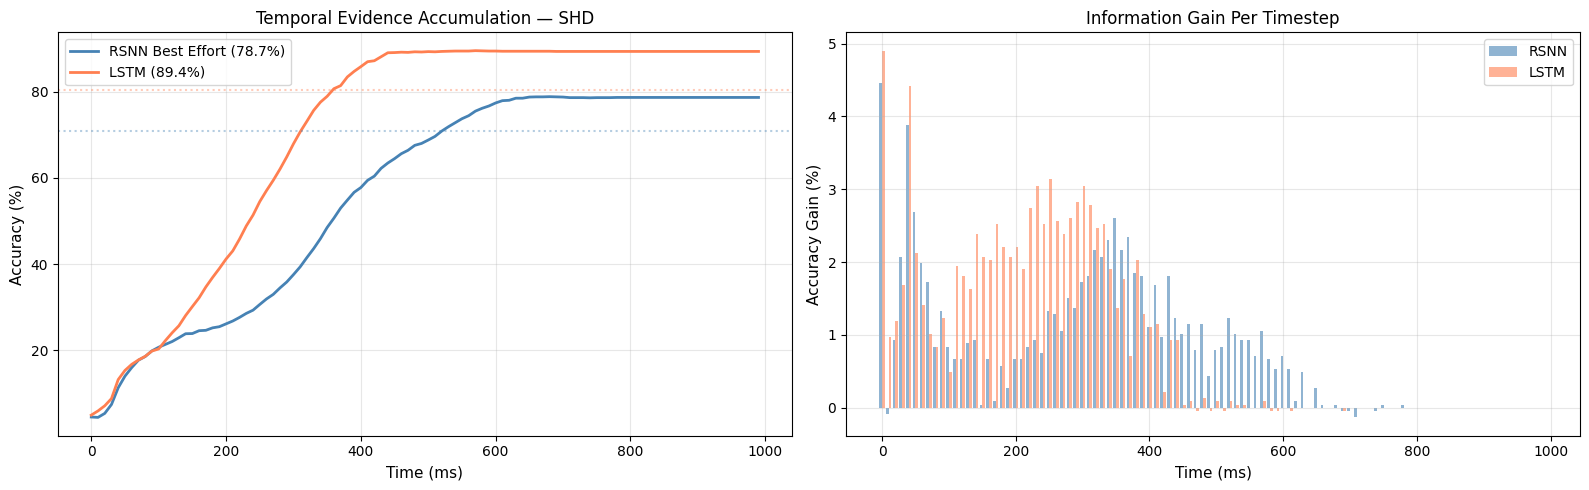

In [25]:
# temporal_acc is from the SNN temporal analysis earlier (Cell 29)
# both arrays have 100 entries (100 time bins)

time_ms = np.arange(100) * 10  # 10ms per bin

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- panel 1: temporal curves ---
axes[0].plot(time_ms, temporal_acc * 100, linewidth=2, color='steelblue',
             label=f'RSNN Best Effort ({best_effort*100:.1f}%)')
axes[0].plot(time_ms, lstm_temporal * 100, linewidth=2, color='coral',
             label=f'LSTM ({acc_lstm*100:.1f}%)')

# 90% of ceiling lines
rsnn_90 = 0.9 * best_effort * 100
lstm_90 = 0.9 * acc_lstm * 100
axes[0].axhline(y=rsnn_90, color='steelblue', linestyle=':', alpha=0.4)
axes[0].axhline(y=lstm_90, color='coral', linestyle=':', alpha=0.4)

axes[0].set_xlabel('Time (ms)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Temporal Evidence Accumulation — SHD', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- panel 2: information gain per step ---
rsnn_gain = np.diff(temporal_acc * 100, prepend=0)
lstm_gain = np.diff(lstm_temporal * 100, prepend=0)
axes[1].bar(time_ms - 2, rsnn_gain, width=4, alpha=0.6, color='steelblue', label='RSNN')
axes[1].bar(time_ms + 2, lstm_gain, width=4, alpha=0.6, color='coral', label='LSTM')
axes[1].set_xlabel('Time (ms)', fontsize=11)
axes[1].set_ylabel('Accuracy Gain (%)', fontsize=11)
axes[1].set_title('Information Gain Per Timestep', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# compute time-to-90%-of-ceiling for both
rsnn_ceiling = best_effort
lstm_ceiling = acc_lstm

rsnn_90_threshold = 0.9 * rsnn_ceiling
lstm_90_threshold = 0.9 * lstm_ceiling

rsnn_t90_idx = np.argmax(temporal_acc >= rsnn_90_threshold)
lstm_t90_idx = np.argmax(lstm_temporal >= lstm_90_threshold)

rsnn_t90_ms = rsnn_t90_idx * 10
lstm_t90_ms = lstm_t90_idx * 10

print("=" * 60)
print("TEMPORAL EFFICIENCY COMPARISON — SHD")
print("=" * 60)
print(f"{'':>25} {'RSNN':>12} {'LSTM':>12}")
print("-" * 50)
print(f"  {'Ceiling accuracy':<23} {rsnn_ceiling*100:>10.1f}% {lstm_ceiling*100:>10.1f}%")
print(f"  {'90% of ceiling':<23} {rsnn_90_threshold*100:>10.1f}% {lstm_90_threshold*100:>10.1f}%")
print(f"  {'Time to 90%':<23} {str(rsnn_t90_ms)+'ms':>12} {str(lstm_t90_ms)+'ms':>12}")
print(f"  {'% of sequence':<23} {rsnn_t90_ms/10:>10.0f}% {lstm_t90_ms/10:>10.0f}%")
print("-" * 50)
if rsnn_t90_ms > 0 and lstm_t90_ms > 0:
    ratio = lstm_t90_ms / rsnn_t90_ms
    print(f"  LSTM needs {ratio:.1f}x longer than RSNN to reach 90% of its own ceiling")
elif rsnn_t90_ms > 0:
    print(f"  LSTM did not reach 90% of ceiling within the sequence")

TEMPORAL EFFICIENCY COMPARISON — SHD
                                  RSNN         LSTM
--------------------------------------------------
  Ceiling accuracy              78.7%       89.4%
  90% of ceiling                70.8%       80.5%
  Time to 90%                    520ms        360ms
  % of sequence                   52%         36%
--------------------------------------------------
  LSTM needs 0.7x longer than RSNN to reach 90% of its own ceiling


## 17. Comparitive Results Summary

In [27]:
print("=" * 70)
print("FULL RESULTS — SHD Benchmark")
print("=" * 70)
print(f"{'Architecture':<35} {'Test Acc':>10} {'Paper':>10} {'Params':>10}")
print("-" * 70)

all_results = [
    ("2L Feed-Forward SNN", best_ff, 0.486, model_ff.count_params()),
    ("RSNN 128 + dropout", best_rsnn, 0.714, model_rsnn.count_params()),
    ("RSNN 256 + dropout", best_rsnn256, 0.730, model_rsnn256.count_params()),
    ("Best Effort RSNN", best_effort, 0.832, model_best.count_params()),
    ("LSTM (2L, 128)", acc_lstm, 0.890, model_lstm.count_params()),
    ("1D-CNN", acc_cnn, 0.924, model_cnn.count_params()),
]
for name, acc, paper, params in all_results:
    gap = (paper - acc) * 100
    print(f"  {name:<33} {acc*100:>8.2f}% {paper*100:>8.1f}% {params:>10,}  ({gap:>+5.1f}%)")
print("-" * 70)
print()
print("Temporal efficiency:")
print(f"  RSNN reaches 90% of {rsnn_ceiling*100:.1f}% ceiling at {rsnn_t90_ms}ms")
print(f"  LSTM reaches 90% of {lstm_ceiling*100:.1f}% ceiling at {lstm_t90_ms}ms")

FULL RESULTS — SHD Benchmark
Architecture                          Test Acc      Paper     Params
----------------------------------------------------------------------
  2L Feed-Forward SNN                  49.69%     48.6%    108,544  ( -1.1%)
  RSNN 128 + dropout                   58.22%     71.4%    108,544  (+13.2%)
  RSNN 256 + dropout                   62.28%     73.0%    249,856  (+10.7%)
  Best Effort RSNN                     78.71%     83.2%    308,226  ( +4.5%)
  LSTM (2L, 128)                       89.40%     89.0%    559,636  ( -0.4%)
  1D-CNN                               89.93%     92.4%    720,468  ( +2.5%)
----------------------------------------------------------------------

Temporal efficiency:
  RSNN reaches 90% of 78.7% ceiling at 520ms
  LSTM reaches 90% of 89.4% ceiling at 360ms


In [28]:
# save everything
import json

shd_full_results = {
    'snn_results': {name: acc for name, acc, _, _ in all_results[:4]},
    'baseline_results': {'LSTM': acc_lstm, 'CNN': acc_cnn},
    'temporal': {
        'rsnn_temporal': temporal_acc.tolist(),
        'lstm_temporal': lstm_temporal.tolist(),
        'rsnn_t90_ms': int(rsnn_t90_ms),
        'lstm_t90_ms': int(lstm_t90_ms),
    }
}
with open('/kaggle/working/shd_full_results.json', 'w') as f:
    json.dump(shd_full_results, f, indent=2)

# also save the temporal arrays as numpy for later cross-domain plotting
np.savez('/kaggle/working/shd_temporal.npz',
         rsnn=temporal_acc, lstm=lstm_temporal,
         rsnn_ceiling=rsnn_ceiling, lstm_ceiling=lstm_ceiling)

print("Saved to shd_full_results.json and shd_temporal.npz")

Saved to shd_full_results.json and shd_temporal.npz
